# Text Emotion Classification with Bidirectional LSTM

This notebook trains a deep learning model to classify emotions in English text.
Given a sentence, the model predicts one of six emotions:
**anger**, **fear**, **joy**, **love**, **sadness**, or **surprise**.

## Pipeline overview
1. **Exploratory Data Analysis** — class distribution, token lengths, word frequency
2. **Text Preprocessing** — lowercasing, stop-word removal, lemmatization
3. **Tokenization & Padding** — integer encoding, max-length selection via p99
4. **GloVe Embeddings** — 200-dimensional pre-trained vectors (fine-tuned)
5. **Bidirectional LSTM** — 3-layer encoder with Dropout and L2 regularization
6. **Class Imbalance** — balanced class weights in the loss function
7. **Evaluation** — Macro F1 as primary metric, systematic error analysis

## Dataset
[Emotions Dataset for NLP](https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp) — ~20 000 English tweets pre-split into train / validation / test.

## Key results
| Metric | Score |
|---|---|
| Accuracy | 0.9295 |
| Macro F1 | 0.8888 |
| Weighted F1 | 0.9303 |


---

## 1. Setup

Install required packages and download NLTK resources.


In [1]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.1 MB/s eta 0:00:00


In [2]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=59ebe7faa1147f20db372866609770e8e4157be294deea70c4ee4ba47abdb118
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('words')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

Import all libraries used in this notebook.


In [4]:
import re
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, f1_score as sk_f1
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, Callback, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras import Input
from tensorflow.keras.initializers import Constant

import warnings
warnings.filterwarnings('ignore')

stop_words = set(stopwords.words('english'))

---

## 2. Exploratory Data Analysis

We examine the dataset structure, class distribution, and token length statistics
across the three splits (train / validation / test).


In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [6]:
path = '/content/drive/MyDrive/datasets/emotions_dataset/'

# Read datasets
df_train = pd.read_csv(path + 'train.txt', names=['Text', 'Emotion'], sep=';')
df_val = pd.read_csv(path + 'val.txt', names=['Text', 'Emotion'], sep=';')
df_test = pd.read_csv(path + 'test.txt', names=['Text', 'Emotion'], sep=';')

In [7]:
# Preview dataset
df_train.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [8]:
# Dataset shape
print(df_train.shape)

(16000, 2)


### Class Distribution

We visualize class imbalance across all three splits in a single consolidated chart.
The dataset is highly imbalanced: `joy` has ~9× more samples than `surprise`.


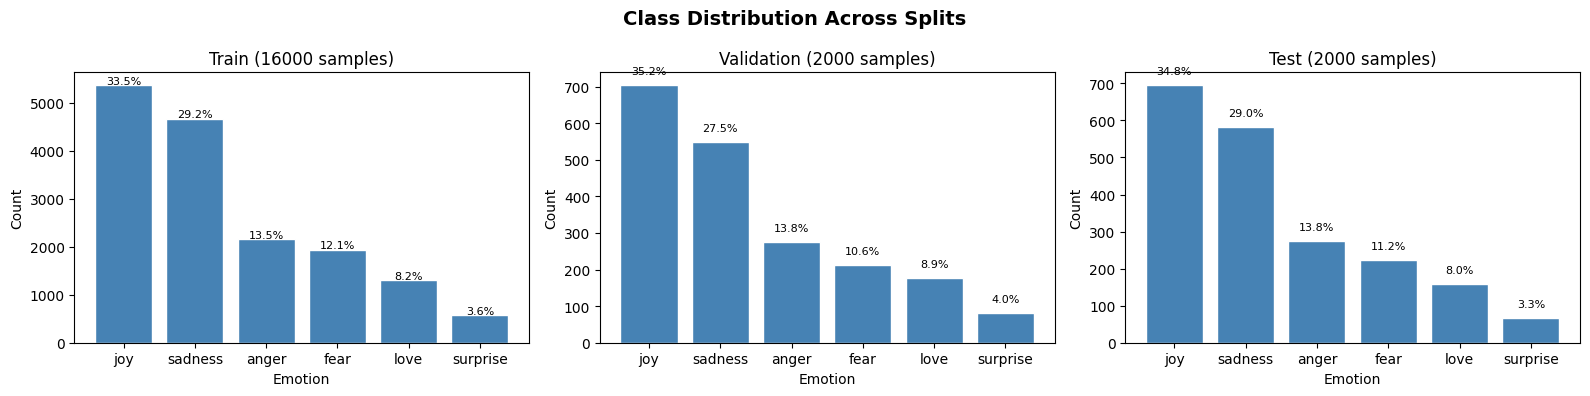

Train class distribution:
Emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572

Imbalance ratio (joy/surprise): 9.4×


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (df, title) in zip(axes, [(df_train, 'Train'), (df_val, 'Validation'), (df_test, 'Test')]):
    counts = df['Emotion'].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{title} ({len(df)} samples)')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Count')
    for j, (lbl, cnt) in enumerate(counts.items()):
        ax.text(j, cnt + 30, f'{cnt/len(df)*100:.1f}%', ha='center', fontsize=8)
plt.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Train class distribution:')
print(df_train['Emotion'].value_counts().to_string())
print(f'\nImbalance ratio (joy/surprise): {df_train["Emotion"].value_counts()["joy"] / df_train["Emotion"].value_counts()["surprise"]:.1f}×')


### Token Length Distribution (raw text)

We analyze how many tokens each sample contains **before** preprocessing.
This guides the choice of `maxlen` for the embedding layer.


Raw token lengths (pre-preprocessing):
  p 50: 17 tokens
  p 75: 25 tokens
  p 90: 35 tokens
  p 95: 41 tokens
  p 99: 52 tokens
  p100: 66 tokens


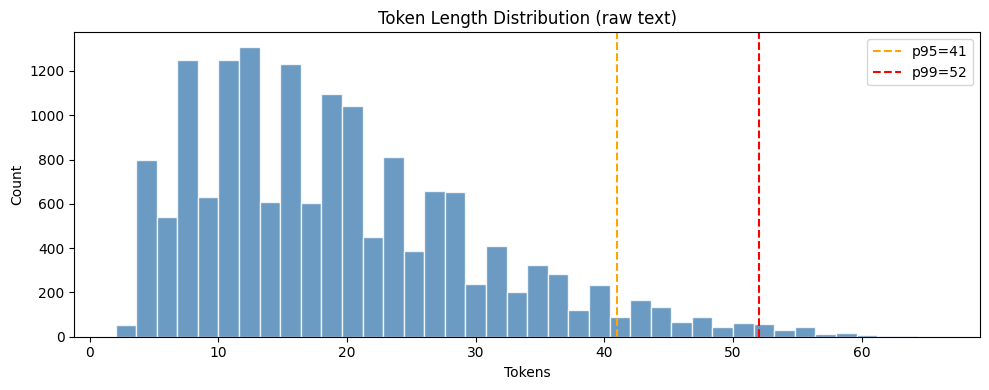

In [10]:
raw_lengths = df_train['Text'].apply(lambda t: len(t.split()))

print('Raw token lengths (pre-preprocessing):')
for p in [50, 75, 90, 95, 99, 100]:
    print(f'  p{p:3d}: {int(np.percentile(raw_lengths, p))} tokens')

plt.figure(figsize=(10, 4))
plt.hist(raw_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
for q, color in [(95, 'orange'), (99, 'red')]:
    v = int(np.percentile(raw_lengths, q))
    plt.axvline(v, color=color, linestyle='--', label=f'p{q}={v}')
plt.title('Token Length Distribution (raw text)')
plt.xlabel('Tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


### Most Frequent Words per Emotion

Top-15 characteristic words for each emotion class, after filtering generic stop-words.
This confirms each class has a distinguishable vocabulary.


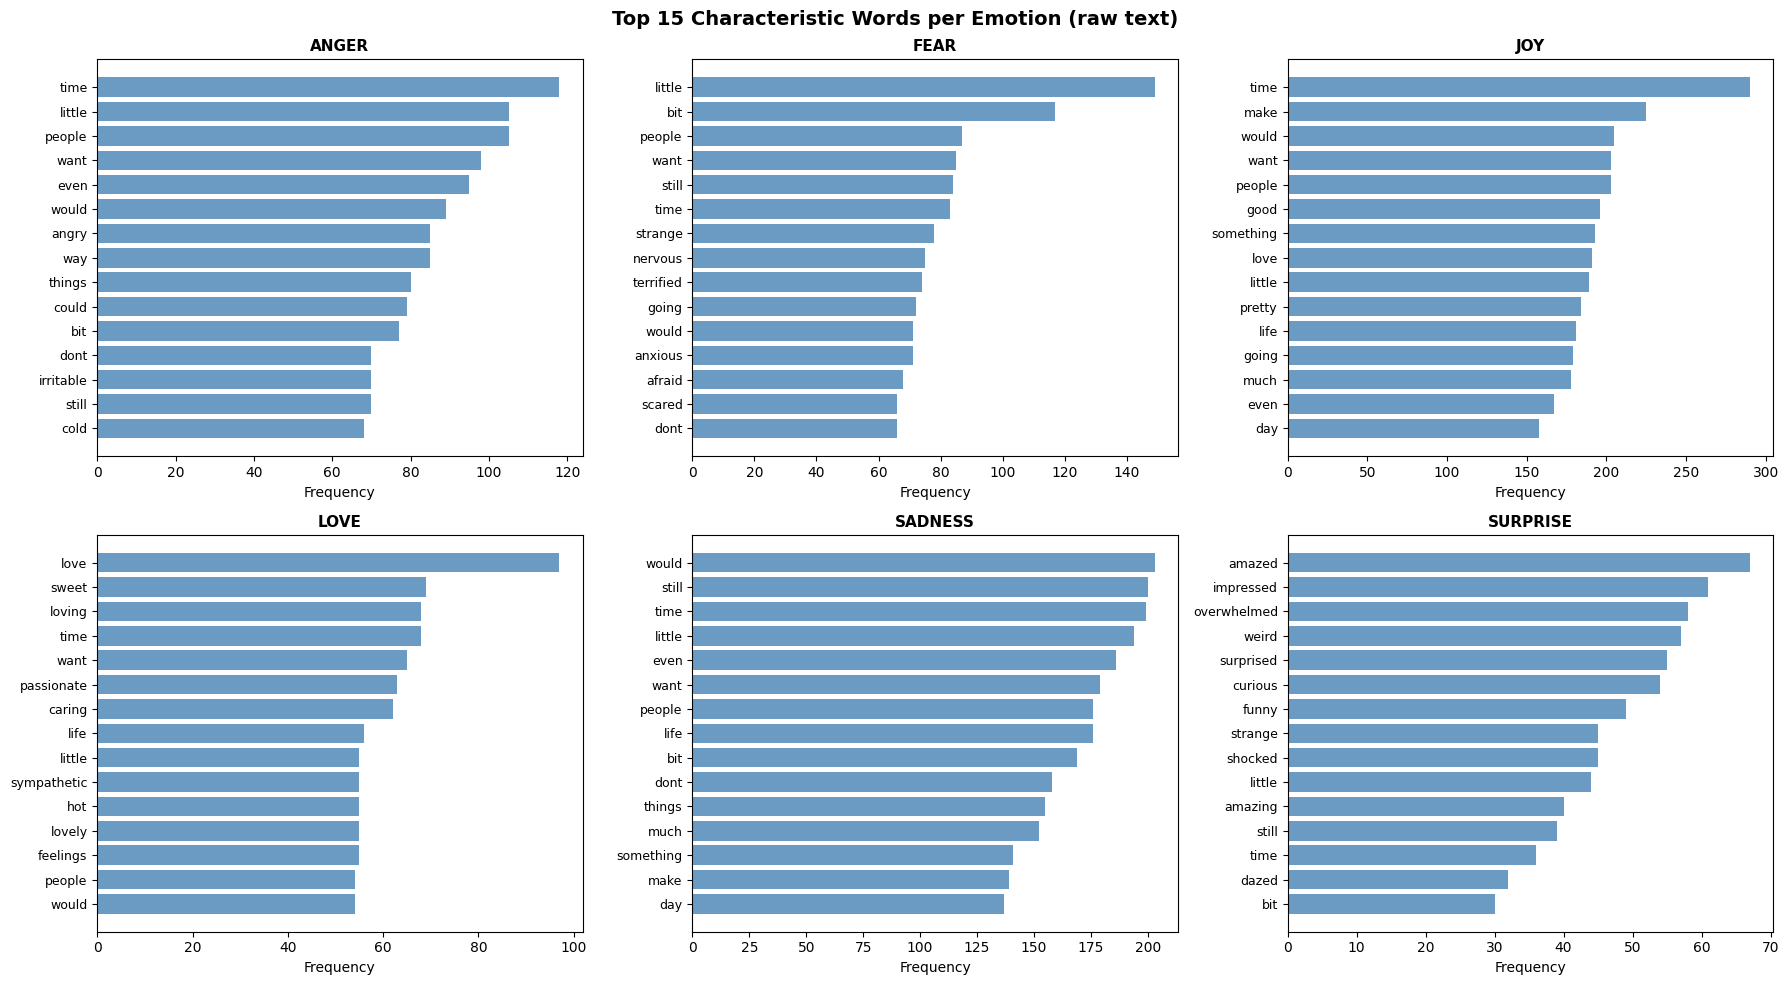

In [11]:
from collections import Counter

emotions = df_train['Emotion'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

generic = stop_words | {'feel', 'feeling', 'im', 'ive', 'like', 'know', 'one', 'get', 'go', 'really', 'think'}

for ax, emotion in zip(axes, sorted(emotions)):
    words = []
    for text in df_train[df_train['Emotion'] == emotion]['Text']:
        words.extend([w.lower() for w in str(text).split() if w.lower() not in generic and len(w) > 2])
    top = Counter(words).most_common(15)
    if not top:
        continue
    labels, values = zip(*top)
    ax.barh(range(len(labels)), values[::-1], color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(list(reversed(labels)), fontsize=9)
    ax.set_title(f'{emotion.upper()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Characteristic Words per Emotion (raw text)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Data Quality Assessment


#### Train split

We check for missing values, exact duplicates, and label conflicts
(same text appearing with two different emotion labels).


In [12]:
# Class distribution
df_train.Emotion.value_counts()

,count
Emotion,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


In [13]:
# Class distribution
df_train.Emotion.value_counts() / df_train.shape[0] * 100

,count
Emotion,
joy,33.51250
sadness,29.16250
anger,13.49375
fear,12.10625
love,8.15000
surprise,3.57500


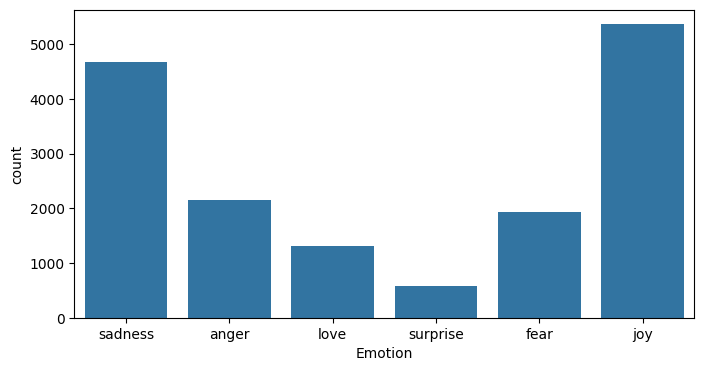

In [14]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_train);


In [15]:
# Check for missing values
df_train.isnull().sum()

,0
Text,0
Emotion,0


In [16]:
# Check for duplicates
df_train.duplicated().sum()

np.int64(1)

In [17]:
# Remove exact duplicates
index = df_train[df_train.duplicated() == True].index
df_train.drop(index, axis = 0, inplace = True)
df_train.reset_index(inplace=True, drop = True)

# Inspect duplicate rows (duplicated in the text but with different emotions)
df_train[df_train['Text'].duplicated() == True]

,Text,Emotion
5067,i feel on the verge of tears from weariness i ...,joy
6133,i still feel a craving for sweet food,love
6563,i tend to stop breathing when i m feeling stre...,anger
7623,i was intensely conscious of how much cash i h...,sadness
7685,im still not sure why reilly feels the need to...,surprise
8246,i am not amazing or great at photography but i...,love
9596,ive also made it with both sugar measurements ...,joy
9687,i had to choose the sleek and smoother feel of...,joy
9769,i often find myself feeling assaulted by a mul...,sadness
9786,i feel im being generous with that statement,joy


In [18]:
# Inspect conflicting labels
df_train[df_train['Text'] == df_train.iloc[7623]['Text']]

,Text,Emotion
1625,i was intensely conscious of how much cash i h...,anger
7623,i was intensely conscious of how much cash i h...,sadness


In [19]:
# Remove texts that appear with different labels
index = df_train[df_train['Text'].duplicated() == True].index
df_train.drop(index, axis = 0, inplace = True)
df_train.reset_index(inplace=True, drop = True)

#### Test split


In [20]:
# Class distribution
df_test.Emotion.value_counts()

,count
Emotion,
joy,695
sadness,581
anger,275
fear,224
love,159
surprise,66


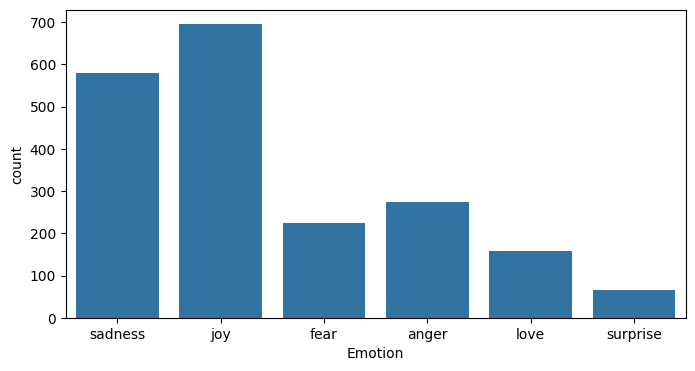

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_test);

In [22]:
# Check for missing values
df_test.isnull().sum()

,0
Text,0
Emotion,0


In [23]:
# Check for duplicates
df_test.duplicated().sum()

np.int64(0)

In [24]:
# Inspect duplicate rows
df_test[df_test['Text'].duplicated() == True]

,Text,Emotion


#### Validation split


In [25]:
# Class distribution
df_val.Emotion.value_counts()

,count
Emotion,
joy,704
sadness,550
anger,275
fear,212
love,178
surprise,81


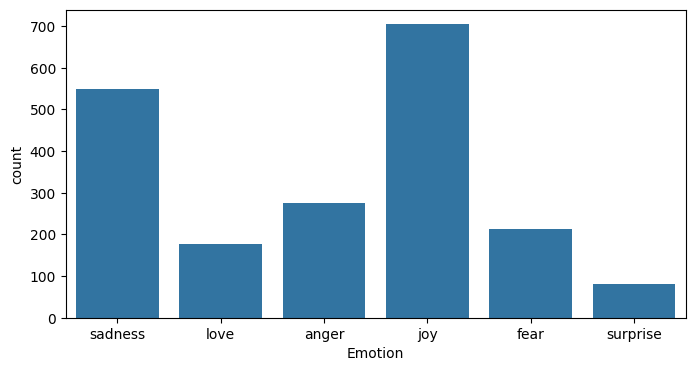

In [26]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_val);

In [27]:
# Check for missing values
df_val.isnull().sum()

,0
Text,0
Emotion,0


In [28]:
# Check for duplicates
df_val.duplicated().sum()

np.int64(0)

In [29]:
# Inspect duplicate rows
df_val[df_val['Text'].duplicated() == True]

,Text,Emotion
603,i have had several new members tell me how com...,joy
1993,i feel so tortured by it,anger


In [30]:
df_val[df_val['Text'] == df_val.iloc[603]['Text']]

,Text,Emotion
300,i have had several new members tell me how com...,love
603,i have had several new members tell me how com...,joy


In [31]:
# Remove texts that appear with different labels
index = df_val[df_val['Text'].duplicated() == True].index
df_val.drop(index, axis = 0, inplace = True)
df_val.reset_index(inplace=True, drop = True)

### Cross-split Leakage Check

Verify no identical samples appear across different splits.


In [32]:
def dataframe_difference(df1, df2, which=None):
    """Find rows which are different between two DataFrames."""

    # Combine the two DataFrames using a merge operation, with the
    # indicator parameter set to True. This adds a column called _merge
    # to the resulting DataFrame, which indicates the source of each row.
    comparison_df = df1.merge(
        df2,
        indicator=True,
        how='outer'
    )

    # Filter the merged DataFrame based on the value of _merge. If which
    # is not specified, return all rows where _merge is not 'both'.
    # Otherwise, return all rows where _merge has the specified value
    if which is None:
        diff_df = comparison_df[comparison_df['_merge'] != 'both']
    else:
        diff_df = comparison_df[comparison_df['_merge'] == which]

    # Return the filtered DataFrame
    return diff_df

In [33]:
dataframe_difference(df_train, df_test, which='both')


,Text,Emotion,_merge


In [34]:
dataframe_difference(df_train, df_val, which='both')


,Text,Emotion,_merge


In [35]:
dataframe_difference(df_val, df_test, which='both')


,Text,Emotion,_merge


---

## 3. Text Preprocessing

The preprocessing pipeline performs:
1. Lowercasing
2. Stop-word removal — **negation words are preserved** (`not`, `never`, `no`, etc.)
3. Number removal
4. Punctuation removal
5. URL removal
6. Lemmatization (WordNet)

Negation words are explicitly kept because they carry strong emotional signal.
For example, *"I do not feel happy"* has the opposite meaning of *"I feel happy"*.


In [36]:
# Negation words that must NOT be removed — they carry emotional signal
NEGATION_WORDS = {
    'no', 'not', 'nor', 'neither', 'never', 'nobody', 'nothing',
    'nowhere', 'none', 'cannot', "can't", "won't", "don't",
    "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't",
    "haven't", "hasn't", "hadn't", "wouldn't", "shouldn't", "couldn't",
    "mustn't", "needn't", "mightn't", "shan't",
}

# Stop words minus negations — used by BOTH dataset and inference preprocessing
filtered_stop_words = stop_words - NEGATION_WORDS


def lemmatization(text):
    lemmatizer = WordNetLemmatizer()
    return ' '.join(lemmatizer.lemmatize(w) for w in text.split())


def remove_stop_words(text):
    return ' '.join(w for w in str(text).split() if w not in filtered_stop_words)


def Removing_numbers(text):
    return ''.join(c for c in text if not c.isdigit())


def lower_case(text):
    return ' '.join(w.lower() for w in text.split())


def Removing_punctuations(text):
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,،-./:;<=>؟?@[\]^_`{|}~"""), ' ', text)
    return ' '.join(text.split()).strip()


def Removing_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)


def normalize_text(df):
    df['Text'] = df['Text'].apply(lower_case)
    df['Text'] = df['Text'].apply(remove_stop_words)
    df['Text'] = df['Text'].apply(Removing_numbers)
    df['Text'] = df['Text'].apply(Removing_punctuations)
    df['Text'] = df['Text'].apply(Removing_urls)
    df['Text'] = df['Text'].apply(lemmatization)
    return df


# BUG FIX v4: explicitly use filtered_stop_words (not stop_words)
def normalized_sentence(sentence):
    sentence = lower_case(sentence)
    sentence = remove_stop_words(sentence)   # uses filtered_stop_words
    sentence = Removing_numbers(sentence)
    sentence = Removing_punctuations(sentence)
    sentence = Removing_urls(sentence)
    sentence = lemmatization(sentence)
    return sentence


# Sanity check
test_neg = 'I do not feel happy at all and never liked this'
print('Original :', test_neg)
print('Processed:', normalized_sentence(test_neg))
print('(negations preserved: not, never)')


Original : I do not feel happy at all and never liked this
Processed: not feel happy never liked
(negations preserved: not, never)


In [37]:
normalized_sentence("My Name is Mohamed. @Tweets,  plays 2022  Egypt_")


'name mohamed tweet play egypt'

In [38]:
df_train= normalize_text(df_train)
df_test= normalize_text(df_test)
df_val= normalize_text(df_val)

### Token Length After Preprocessing

After cleaning, sequences become much shorter.
We use the **99th percentile** (p99) of token lengths as `MAX_LEN`,
covering 99% of samples while eliminating wasteful padding.
This reduces `maxlen` from **229 → ~26** tokens — an 8× speed-up with no information loss.


Token lengths AFTER preprocessing:
  p 50: 8 tokens
  p 75: 12 tokens
  p 90: 17 tokens
  p 95: 20 tokens
  p 99: 26 tokens
  p100: 35 tokens

MAX_LEN chosen (p99): 26 tokens
(original maxlen was 229 — 8× larger than needed)


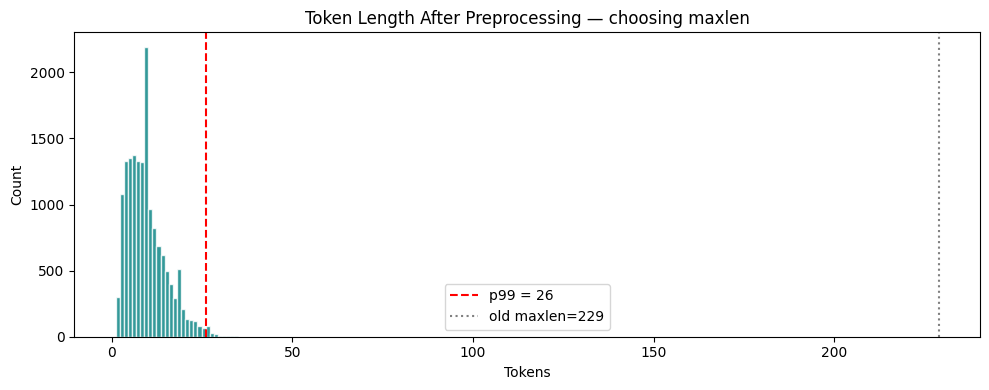

In [39]:
post_lengths = df_train['Text'].apply(lambda t: len(str(t).split()))

print('Token lengths AFTER preprocessing:')
for p in [50, 75, 90, 95, 99, 100]:
    print(f'  p{p:3d}: {int(np.percentile(post_lengths, p))} tokens')

MAX_LEN = int(np.percentile(post_lengths, 99))  # p99 — covers 99% of texts
print(f'\nMAX_LEN chosen (p99): {MAX_LEN} tokens')
print(f'(original maxlen was 229 — {229 // MAX_LEN}× larger than needed)')

plt.figure(figsize=(10, 4))
plt.hist(post_lengths, bins=30, color='teal', edgecolor='white', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'p99 = {MAX_LEN}')
plt.axvline(229, color='gray', linestyle=':', label='old maxlen=229')
plt.title('Token Length After Preprocessing — choosing maxlen')
plt.xlabel('Tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


---

## 4. Label Encoding

Separate features (`X`) and labels (`y`) for each split,
then encode string labels to integer class indices.


In [40]:
# Separate features and labels
X_train = df_train['Text']
y_train = df_train['Emotion']

X_test = df_test['Text']
y_test = df_test['Emotion']

X_val = df_val['Text']
y_val = df_val['Emotion']

---

## 5. Class Imbalance

The dataset is heavily skewed. We use **balanced class weights** (inverse class frequency)
passed directly to `model.fit()`. This penalizes errors on rare classes more strongly
without requiring data augmentation.


Class weights:
  surprise  : 4.686
  love      : 2.049
  fear      : 1.377
  anger     : 1.235
  sadness   : 0.571
  joy       : 0.497


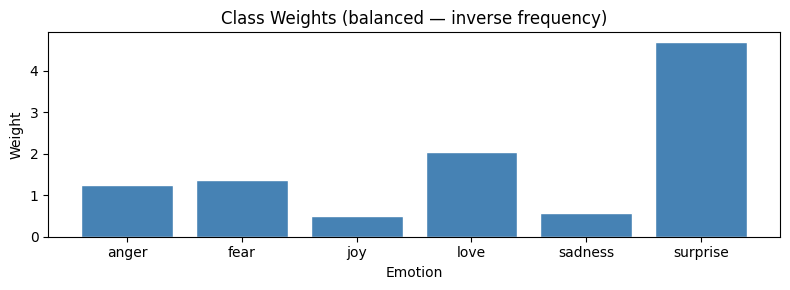

In [41]:
# Class weights (balanced) — sole balancing strategy
raw_labels = df_train['Emotion'].values
classes    = np.unique(raw_labels)
weights    = compute_class_weight('balanced', classes=classes, y=raw_labels)
class_weight_dict = dict(zip(range(len(classes)), weights))

print('Class weights:')
for cls, w in sorted(zip(classes, weights), key=lambda x: x[1], reverse=True):
    print(f'  {cls:10s}: {w:.3f}')

# Visualize
plt.figure(figsize=(8, 3))
plt.bar(classes, weights, color='steelblue', edgecolor='white')
plt.title('Class Weights (balanced — inverse frequency)')
plt.ylabel('Weight')
plt.xlabel('Emotion')
plt.tight_layout()
plt.show()


In [42]:
# Encode labels (using original train set — no oversampling)
le = LabelEncoder()
y_train = le.fit_transform(df_train['Emotion'])
y_test  = le.transform(df_test['Emotion'])
y_val   = le.transform(df_val['Emotion'])

X_train = df_train['Text']
X_test  = df_test['Text']
X_val   = df_val['Text']

print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Train samples:', len(X_train))


Class mapping: {'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}
Train samples: 15969


In [43]:
y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)
y_val   = to_categorical(y_val)


---

## 6. Tokenization

We fit a word-level tokenizer on the combined train + test vocabulary.
Out-of-vocabulary tokens are mapped to a special `UNK` token.


In [44]:
# Tokenize on combined train+test vocabulary
tokenizer = Tokenizer(oov_token='UNK')
tokenizer.fit_on_texts(pd.concat([X_train, X_test], axis=0))
print(f'Vocabulary size: {len(tokenizer.word_index):,} words')


Vocabulary size: 14,334 words


In [45]:
sequences_train = tokenizer.texts_to_sequences(X_train)
sequences_test  = tokenizer.texts_to_sequences(X_test)
sequences_val   = tokenizer.texts_to_sequences(X_val)


### Sequence Padding

All sequences are padded or truncated to `MAX_LEN` (the p99 value computed above).
Padding is added at the end; truncation removes tokens from the right.


In [46]:
# Use MAX_LEN computed during EDA (p99 of post-preprocessing token lengths)
# MAX_LEN is already defined above; padded sequences below
X_train_pad = pad_sequences(sequences_train, maxlen=MAX_LEN, truncating='post', padding='post')
X_test_pad  = pad_sequences(sequences_test,  maxlen=MAX_LEN, truncating='post', padding='post')
X_val_pad   = pad_sequences(sequences_val,   maxlen=MAX_LEN, truncating='post', padding='post')

# Promote to consistent variable names used by model
X_train = X_train_pad
X_test  = X_test_pad
X_val   = X_val_pad

vocabSize = len(tokenizer.index_word) + 1
print(f'Vocabulary size : {vocabSize:,}')
print(f'Sequence length : {MAX_LEN} (was 229)')
print(f'X_train shape   : {X_train.shape}')


Vocabulary size : 14,335
Sequence length : 26 (was 229)
X_train shape   : (15969, 26)


---

## 7. Word Embeddings

We initialize the `Embedding` layer with [GloVe 200-dimensional](https://nlp.stanford.edu/projects/glove/) pre-trained vectors.
Setting `trainable=True` allows the embeddings to be fine-tuned on the emotion domain.


In [47]:
# Read GloVE embeddings

path_to_glove_file = '/content/drive/MyDrive/datasets/glove-global-vectors-for-word-representation/glove.6B.200d.txt'
num_tokens = vocabSize
embedding_dim = 200 #latent factors or features
hits = 0
misses = 0
embeddings_index = {}

We initialize an embedding matrix of shape `(vocab_size, 200)` with zeros,
then fill each row with the corresponding GloVe vector.
Words not found in GloVe remain at zero (reported as *misses*).


In [48]:
# Read word vectors
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs
print("Found %s word vectors." % len(embeddings_index))

# Assign word vectors to our dictionary/vocabulary
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))


Found 400000 word vectors.
Converted 13252 words (1082 misses)


---

## 8. Model Architecture

The classifier is a **3-layer Bidirectional LSTM**:

| Layer | Details |
|---|---|
| Embedding | GloVe 200d, `trainable=True` |
| BiLSTM × 3 | 256 → 128 → 128 units; internal `Dropout(0.2)` |
| Dropout | 0.3 after each BiLSTM block |
| Dense | 6 units, softmax; `L2(1e-4)` regularization |

**Loss**: `CategoricalCrossentropy(label_smoothing=0.1)` — prevents overconfidence on ambiguous emotion pairs (e.g. *joy / love*).

**Optimizer**: Adam, `lr=0.005`


In [49]:
adam = Adam(learning_rate=0.005)

model = Sequential([
    Input(shape=(X_train.shape[1],), dtype='int32'),

    # GloVe 200d — trainable (fine-tune on emotional domain)
    Embedding(vocabSize, 200,
              embeddings_initializer=Constant(embedding_matrix),
              trainable=True),

    Bidirectional(LSTM(256, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
    Dropout(0.3),

    Dense(6, activation='softmax', kernel_regularizer=l2(1e-4)),
])

# Label smoothing=0.1: softens the joy/love boundary (53 persistent errors)
# Prevents the model from being over-confident on ambiguous emotion pairs
model.compile(
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=adam,
    metrics=['accuracy'],
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 26, 200)        │     2,867,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 26, 512)        │       935,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 26, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,855,102 (18.52 MB)

 Trainable params: 4,855,102 (18.52 MB)

 Non-trainable params: 0 (0.00 B)

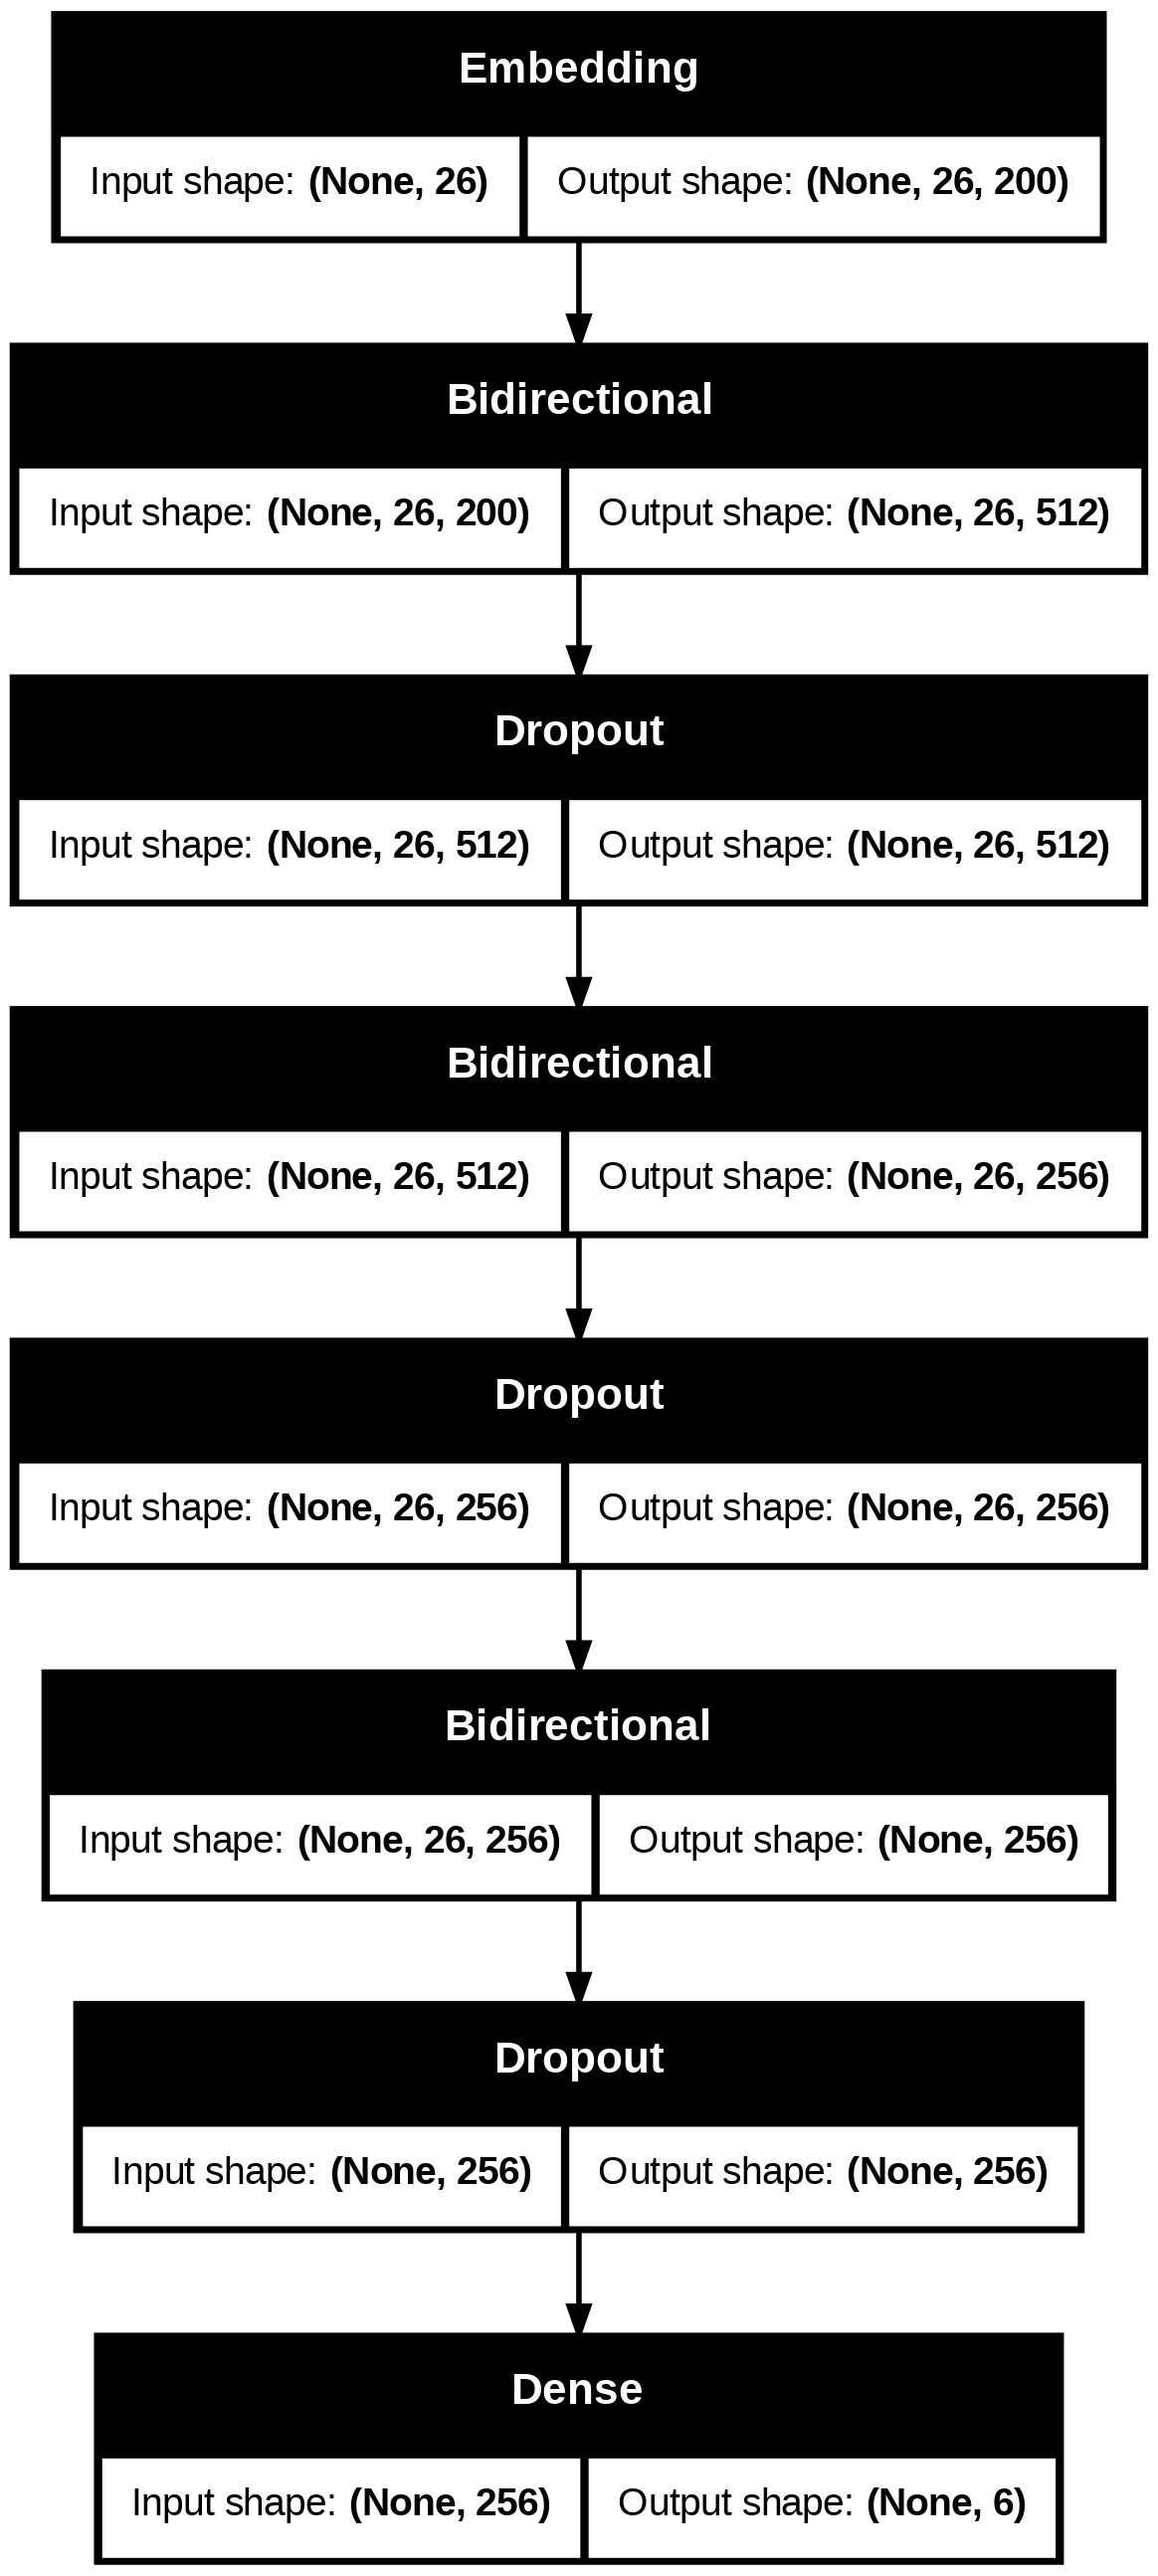

In [50]:
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True)

---

## 9. Training

| Callback | Purpose |
|---|---|
| `MacroF1Callback` | Computes validation Macro F1 at the end of each epoch |
| `EarlyStopping` | Stops when `val_macro_f1` stagnates (`patience=7`, `restore_best_weights=True`) |
| `ReduceLROnPlateau` | Reduces LR by ×0.7 when `val_loss` plateaus for 3 epochs |


In [51]:
class MacroF1Callback(Callback):
    """Computes macro-averaged F1 on validation set at end of each epoch."""
    def __init__(self, val_data):
        super().__init__()
        self.X_val, self.y_val = val_data

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        y_true = np.argmax(self.y_val, axis=1)
        macro  = sk_f1(y_true, y_pred, average='macro', zero_division=0)
        logs['val_macro_f1'] = macro
        print(f'  — val_macro_f1: {macro:.4f}')


macro_f1_cb = MacroF1Callback(val_data=(X_val, y_val))

early_stop = EarlyStopping(
    monitor='val_macro_f1',
    patience=7,            # increased from 4 → gives more time to plateau
    restore_best_weights=True,
    mode='max',
)


In [52]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.7,          # less aggressive than 0.5 (was freezing model)
    patience=5,          # was 3 — gives more room before reducing
    min_lr=1e-5,         # was 1e-6 — prevents total freeze
    verbose=1,
)

macro_f1_cb = MacroF1Callback(val_data=(X_val, y_val))

early_stop = EarlyStopping(
    monitor='val_macro_f1',
    patience=5,           # was 7 — model peaks at epoch ~11
    restore_best_weights=True,
    mode='max',
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    verbose=1,
    batch_size=256,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stop, macro_f1_cb, reduce_lr],
)


Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.2686 - loss: 1.7369  — val_macro_f1: 0.8456
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 498ms/step - accuracy: 0.2716 - loss: 1.7314 - val_accuracy: 0.8684 - val_loss: 0.7583 - val_macro_f1: 0.8456 - learning_rate: 0.0050
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.8960 - loss: 0.6286  — val_macro_f1: 0.8937
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 395ms/step - accuracy: 0.8961 - loss: 0.6283 - val_accuracy: 0.9194 - val_loss: 0.5856 - val_macro_f1: 0.8937 - learning_rate: 0.0050
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9362 - loss: 0.5496  — val_macro_f1: 0.8994
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 395ms/step - accuracy: 0.9362 - loss: 0.5496 - val_accuracy: 0.9244 - val_loss: 0.5863 - val_macro_f1: 0.8994 - learning_rate: 0.0050
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9503 - loss: 0.5120  — val_macro_f1: 0.9038
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 395ms/step - accuracy: 0.9503 - lo

In [53]:
# Evaluate model performance
model.evaluate(X_val, y_val, verbose=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9455 - loss: 0.6000


[0.6197413206100464, 0.9379379153251648]

In [54]:
# Evaluate model performance
model.evaluate(X_test, y_test, verbose=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9286 - loss: 0.6503


[0.64389967918396, 0.9319999814033508]

In [55]:
predicted = model.predict(X_test)
y_pred = predicted.argmax(axis=-1)

print(classification_report(le.transform(df_test['Emotion']), y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       275
           1       0.92      0.90      0.91       224
           2       0.97      0.93      0.95       695
           3       0.78      0.89      0.83       159
           4       0.97      0.97      0.97       581
           5       0.74      0.86      0.80        66

    accuracy                           0.93      2000
   macro avg       0.88      0.91      0.90      2000
weighted avg       0.94      0.93      0.93      2000



### Performance Summary

For imbalanced datasets, **Macro F1** is the primary metric — it treats all classes equally.
**Weighted F1** weights each class by its support and reflects real-world prevalence.


In [56]:
y_true_int = le.transform(df_test['Emotion'])

macro_f1    = sk_f1(y_true_int, y_pred, average='macro',    zero_division=0)
weighted_f1 = sk_f1(y_true_int, y_pred, average='weighted', zero_division=0)
acc_val     = accuracy_score(y_true_int, y_pred)

print('=' * 40)
print(f'  Accuracy      : {acc_val:.4f}')
print(f'  Macro F1      : {macro_f1:.4f}  ← principal')
print(f'  Weighted F1   : {weighted_f1:.4f}')
print('=' * 40)


  Accuracy      : 0.9320
  Macro F1      : 0.8975  ← principal
  Weighted F1   : 0.9330


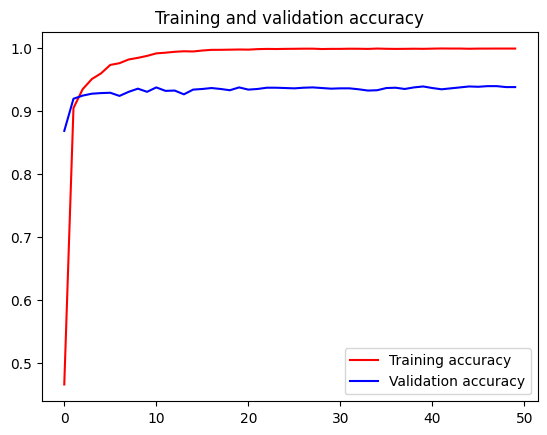

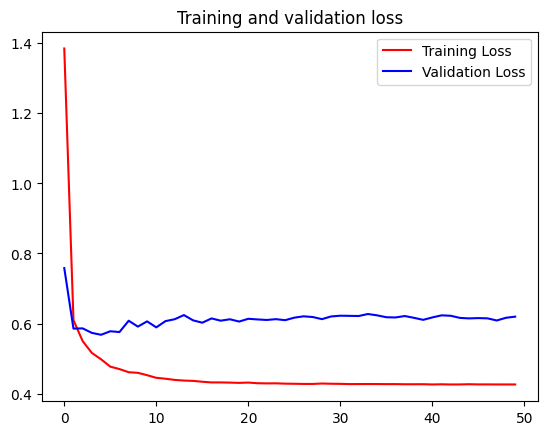

In [57]:
# Visualize Loss & Accuracy

%matplotlib inline
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

---

## 10. Inference

To classify a new sentence:
1. Apply the same preprocessing pipeline (`normalized_sentence()`)
2. Tokenize and pad to `MAX_LEN`
3. The predicted class is the `argmax` of the softmax output


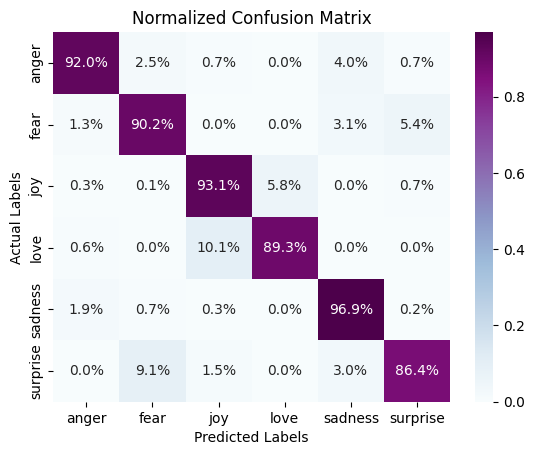

In [58]:
# After training
class_names = le.classes_

# Convert to integer labels
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test
y_pred_classes = np.argmax(y_pred, axis=1) if y_pred.ndim > 1 else y_pred

# Gerar a matriz
cm = confusion_matrix(y_true, y_pred_classes, labels=range(len(class_names)), normalize='true')

# Plotar com nomes reais
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
sns.heatmap(df_cm, annot=True, fmt=".1%", cmap='BuPu', annot_kws={'size': 10})
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Normalized Confusion Matrix')
plt.show()

---

## 11. Error Analysis

We inspect which classes are most confused and display misclassified examples.
This reveals linguistic patterns the model still struggles with
(e.g. *joy ↔ love*, *fear ↔ surprise*).


In [59]:
from sklearn.metrics import f1_score as sk_f1

# Rebuild true/pred arrays
y_true_arr = np.argmax(y_test, axis=1)
y_pred_arr = np.argmax(predicted, axis=1)

# Per-class F1
per_class_f1 = sk_f1(y_true_arr, y_pred_arr, average=None, zero_division=0)
print('Per-class F1:')
for cls, score in sorted(zip(class_names, per_class_f1), key=lambda x: x[1]):
    bar = '█' * int(score * 20)
    print(f'  {cls:10s}: {score:.3f} {bar}')

# Most-confused pairs
print('\nTop confused pairs (true → predicted):')
errors = [(class_names[t], class_names[p])
          for t, p in zip(y_true_arr, y_pred_arr) if t != p]
from collections import Counter
for (true_lbl, pred_lbl), cnt in Counter(errors).most_common(10):
    print(f'  {true_lbl:10s} → {pred_lbl:10s}: {cnt} errors')


Per-class F1:
  surprise  : 0.797 ███████████████
  love      : 0.833 ████████████████
  fear      : 0.910 ██████████████████
  anger     : 0.928 ██████████████████
  joy       : 0.949 ██████████████████
  sadness   : 0.967 ███████████████████

Top confused pairs (true → predicted):
  joy        → love      : 40 errors
  love       → joy       : 16 errors
  fear       → surprise  : 12 errors
  anger      → sadness   : 11 errors
  sadness    → anger     : 11 errors
  fear       → sadness   : 7 errors
  anger      → fear      : 7 errors
  surprise   → fear      : 6 errors
  joy        → surprise  : 5 errors
  sadness    → fear      : 4 errors


In [60]:
worst_class = class_names[per_class_f1.argmin()]
worst_idx   = class_names.tolist().index(worst_class)

# Recover original (post-preproc) test texts
test_texts = df_test['Text'].values

print(f'Worst class: "{worst_class}" (F1={per_class_f1.min():.3f})')
print(f'Sample misclassifications:\n')
count = 0
for idx, (t, p) in enumerate(zip(y_true_arr, y_pred_arr)):
    if t == worst_idx and t != p:
        print(f'  True: {class_names[t]:10s} | Pred: {class_names[p]:10s}')
        print(f'  Text: {test_texts[idx]}')
        print()
        count += 1
        if count >= 8:
            break


Worst class: "surprise" (F1=0.797)
Sample misclassifications:

  True: surprise   | Pred: fear      
  Text: uncomfortable feeling weird feeling sure contraction since never really felt contraction jared jacked pitocin

  True: surprise   | Pred: joy       
  Text: practice meditation feel overwhelmed hopefully become successful peaceful practice

  True: surprise   | Pred: sadness   
  Text: feel ludicrous wasting space trite looked book first come something little original

  True: surprise   | Pred: fear      
  Text: feel shame strange way

  True: surprise   | Pred: fear      
  Text: stay distanced others feel strange sometimes feel like new friendship growing forming

  True: surprise   | Pred: sadness   
  Text: feel betrayed coz backstabber no ground accusation amazed people ability thing

  True: surprise   | Pred: fear      
  Text: feel weird scattered wonder million different thing

  True: surprise   | Pred: fear      
  Text: ive blogged feel strange



In [61]:
# Classify custom sample

sentences = [
            "He's over the moon about being accepted to the university",
            "Your point on this certain matter made me outrageous, how can you say so? This is insane.",
            "I can't do it, I'm not ready to lose anything, just leave me alone",
            "Merlin's beard harry, you can cast the Patronus charm! I'm amazed!"
            ]
for sentence in sentences:
    print(sentence)
    sentence = normalized_sentence(sentence)
    sentence = tokenizer.texts_to_sequences([sentence])
    sentence = pad_sequences(sentence, maxlen=MAX_LEN, truncating='pre')
    result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
    proba =  np.max(model.predict(sentence))
    print(f"{result} : {proba}\n\n")

He's over the moon about being accepted to the university
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
anger : 0.37686675786972046


Your point on this certain matter made me outrageous, how can you say so? This is insane.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
anger : 0.41212236881256104


I can't do it, I'm not ready to lose anything, just leave me alone
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
sadness : 0.3143368363380432


Merlin's beard harry, you can cast the Patronus charm! I'm amazed!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
anger : 0.2821032404899597




In [62]:
sentence= 'my old brother is dead'
print(sentence)
sentence = normalized_sentence(sentence)
sentence = tokenizer.texts_to_sequences([sentence])
sentence = pad_sequences(sentence, maxlen=MAX_LEN, truncating='pre')
result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
proba =  np.max(model.predict(sentence))
print(f"{result} : {proba}\n\n")

my old brother is dead
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
anger : 0.3807562589645386




In [63]:
sentence= 'Im feeling sad today'
print(sentence)
sentence = normalized_sentence(sentence)
sentence = tokenizer.texts_to_sequences([sentence])
sentence = pad_sequences(sentence, maxlen=MAX_LEN, truncating='pre')
result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
proba =  np.max(model.predict(sentence))
print(f"{result} : {proba}\n\n")

Im feeling sad today
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
sadness : 0.2992212474346161


